In [447]:
import numpy as np
import pandas as pd
import json
import matplotlib.pyplot as plt
import pyparsing as pp

In [448]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [449]:
def load_json(filename):
  with open (filename, "r", encoding ="utf-8") as f:
    query = json.load(f)
    return query

In [450]:
query0 = load_json("/content/drive/MyDrive/Colab Notebooks/475/results/query0.json")
print(query0)

query1 = load_json("/content/drive/MyDrive/Colab Notebooks/475/results/query1.json")
print(query1)

query2 = load_json("/content/drive/MyDrive/Colab Notebooks/475/results/query2.json")
print(query2)

query3 = load_json("/content/drive/MyDrive/Colab Notebooks/475/results/query3.json")
print(query3)



{'k': 10, 'seed': {'artist': 'Gorillaz', 'song': 'Feel Good Inc.', 'album_name': ''}, 'features': {'popularity': 0, 'danceability': 0, 'energy': 0, 'key': 0, 'valence': 0, 'tempo': 0, 'duration_ms': 0}, 'constraints': {'include': {'genres': [], 'lang': [], 'artist': [], 'song': [], 'album_name': [], 'release': []}, 'exclude': {'genres': [], 'lang': [], 'artist': ["'Gorillaz'"], 'song': [], 'album_name': [], 'release': []}}}
{'k': 10, 'seed': {'artist': 'Gorillaz', 'song': 'Feel Good Inc.', 'album_name': ''}, 'features': {'popularity': 0, 'danceability': 0, 'energy': 0, 'key': 1.0, 'valence': 0, 'tempo': 0, 'duration_ms': 0}, 'constraints': {'include': {'genres': ['pop'], 'lang': ["'en'"], 'artist': [], 'song': [], 'album_name': [], 'release': ['2010']}, 'exclude': {'genres': [], 'lang': [], 'artist': ["'Gorillaz'"], 'song': [], 'album_name': [], 'release': []}}}
{'k': 10, 'seed': {'artist': 'Gorillaz', 'song': 'Feel Good Inc.', 'album_name': ''}, 'features': {'popularity': 0, 'danceabi

In [453]:
query0["seed"]
query1["seed"]
query2["seed"]
query3["seed"]

query = query3

In [454]:
metadata_df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/475/id_metadata.csv",  sep="\t")
info_df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/475/id_information.csv",  sep="\t")
lang_df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/475/id_lang.csv",  sep="\t")
genres_df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/475/id_genres.csv",  sep="\t")
tags_df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/475/id_tags.csv",  sep="\t")
dataframes = [metadata_df, info_df, lang_df, genres_df, tags_df]


In [455]:
metadata_df.head()

,id,spotify_id,popularity,release,danceability,energy,key,mode,valence,tempo,duration_ms
0,0009fFIM1eYThaPg,3eObKIfHKJ1nAPh0wTxFCc,12.0,2009,0.635,0.746,6.0,1.0,0.548,110.973,229947
1,0010xmHR6UICBOYT,27szvF97Tu95GxN98N52fy,46.0,2013,0.591,0.513,7.0,0.0,0.263,172.208,325096
2,002Jyd0vN4HyCpqL,273lBFpxUCwisTpdnF9cVb,31.0,1974,0.319,0.925,2.0,1.0,0.658,157.630,285693
3,006TYKNjNxWjfKjy,1qZgergQ41vaD4zBf3AKXR,33.0,2017,0.432,0.979,7.0,1.0,0.162,90.008,332867
4,007LIJOPQ4Sb98qV,6rVxJ3sN3Cz40MSLavbG1K,19.0,2009,0.357,0.708,9.0,1.0,0.470,123.904,326067


In [456]:
info_df.head()

,id,artist,song,album_name
0,0009fFIM1eYThaPg,Cheryl,Rain on Me,3 Words
1,0010xmHR6UICBOYT,Oddisee,After Thoughts,The Beauty in All
2,002Jyd0vN4HyCpqL,Blue Öyster Cult,ME 262,Secret Treaties
3,006TYKNjNxWjfKjy,Rhapsody,Flames of Revenge,Legendary Years (Re-Recorded)
4,007LIJOPQ4Sb98qV,The Chameleons,Nostalgia,What Does Anything Mean? Basically (2009 Remas...


In [457]:
lang_df.head()

,id,lang
0,0009fFIM1eYThaPg,en
1,0010xmHR6UICBOYT,en
2,002Jyd0vN4HyCpqL,en
3,006TYKNjNxWjfKjy,en
4,007LIJOPQ4Sb98qV,en


In [458]:
genres_df.head()

,id,genres
0,0009fFIM1eYThaPg,pop
1,0010xmHR6UICBOYT,underground hip hop
2,002Jyd0vN4HyCpqL,"hard rock,rock,classic rock"
3,006TYKNjNxWjfKjy,"symphonic metal,power metal,symphonic power metal"
4,007LIJOPQ4Sb98qV,"post-punk,new wave"


In [459]:
tags_df.head()

,id,tags
0,0009fFIM1eYThaPg,"pop,british,female vocalists,dance,cheryl cole"
1,0010xmHR6UICBOYT,"instrumental hip-hop,underground hip hop,instr..."
2,002Jyd0vN4HyCpqL,"hard rock,rock,classic rock,american artist"
3,006TYKNjNxWjfKjy,"symphonic metal,power metal,symphonic power metal"
4,007LIJOPQ4Sb98qV,"post-punk,new wave,1985"


In [460]:
search_df = pd.concat([metadata_df.set_index("id"), info_df.set_index("id"),
                       lang_df.set_index("id"), genres_df.set_index("id"), tags_df.set_index("id")], axis=1)
search_df = search_df.reset_index()

In [461]:
search_df.head()

,id,spotify_id,popularity,release,danceability,energy,key,mode,valence,tempo,duration_ms,artist,song,album_name,lang,genres,tags
0,0009fFIM1eYThaPg,3eObKIfHKJ1nAPh0wTxFCc,12.0,2009,0.635,0.746,6.0,1.0,0.548,110.973,229947,Cheryl,Rain on Me,3 Words,en,pop,"pop,british,female vocalists,dance,cheryl cole"
1,0010xmHR6UICBOYT,27szvF97Tu95GxN98N52fy,46.0,2013,0.591,0.513,7.0,0.0,0.263,172.208,325096,Oddisee,After Thoughts,The Beauty in All,en,underground hip hop,"instrumental hip-hop,underground hip hop,instr..."
2,002Jyd0vN4HyCpqL,273lBFpxUCwisTpdnF9cVb,31.0,1974,0.319,0.925,2.0,1.0,0.658,157.630,285693,Blue Öyster Cult,ME 262,Secret Treaties,en,"hard rock,rock,classic rock","hard rock,rock,classic rock,american artist"
3,006TYKNjNxWjfKjy,1qZgergQ41vaD4zBf3AKXR,33.0,2017,0.432,0.979,7.0,1.0,0.162,90.008,332867,Rhapsody,Flames of Revenge,Legendary Years (Re-Recorded),en,"symphonic metal,power metal,symphonic power metal","symphonic metal,power metal,symphonic power metal"
4,007LIJOPQ4Sb98qV,6rVxJ3sN3Cz40MSLavbG1K,19.0,2009,0.357,0.708,9.0,1.0,0.470,123.904,326067,The Chameleons,Nostalgia,What Does Anything Mean? Basically (2009 Remas...,en,"post-punk,new wave","post-punk,new wave,1985"


In [462]:
print(search_df.shape)

(109269, 17)


In [463]:
for col in metadata_df.columns:
    print(f"{col} Max {np.max(np.array(metadata_df[col]))}")
    print(f"{col} Min {np.min(np.array(metadata_df[col]))}")


id Max zzzwh2ktIWjsR7xp
id Min 0009fFIM1eYThaPg
spotify_id Max 7zzZmpw8L66ZPjH1M6qmOs
spotify_id Min 000CfxgH11DeiTY9oCvZLJ
popularity Max 95.0
popularity Min 0.0
release Max 2019
release Min 1013
danceability Max 0.988
danceability Min 0.0
energy Max 1.0
energy Min 0.0
key Max 11.0
key Min 0.0
mode Max 1.0
mode Min 0.0
valence Max 0.998
valence Min 0.0
tempo Max 242.903
tempo Min 0.0
duration_ms Max 4995315
duration_ms Min 7229


In [464]:
def get_song_id(song, info_df):
    # take selection and projection
    # of id_information to get seed
    # song id from given song title and artist name
    # filter for non empty attributes
    attributes = {k:v for k,v in song.items() if v}

    # get keys and values from filtered attributes
    # with keys selecting for columns
    # and values used for comparison
    cols = list(attributes.keys())
    vals = list(attributes.values())

    # then do selection and take projection of row "id"
    return info_df.loc[(info_df[cols] == vals).all(axis=1), "id"]

In [465]:
song_id = get_song_id(query0["seed"], info_df).item()
print(type(song_id))
print(song_id)

<class 'str'>
uQUCBofXJAQuX3pV


In [466]:
search_df = pd.concat([metadata_df.set_index("id"), info_df.set_index("id"),
                       lang_df.set_index("id"), genres_df.set_index("id"), tags_df.set_index("id")], axis=1)
search_df = search_df.reset_index()

In [467]:
def parse_expression(col, expr):

    # define boolean operators for filtering
    ops = ['>=', '<=', '>', '<']
    op = pp.one_of(ops)

    # define atom for parsing
    atom = (pp.Optional(op, default="==")) + (pp.Word(pp.nums) | pp.Word(pp.alphas)| pp.quoted_string)
    atom.set_parse_action(lambda toks: f"{col}"+"".join(toks))

    # define pattern
    # use lambda on extracted tokens to add parentheses to expressions
    # i.e year>=2018 & year <= 2025 || year==2005
    # will be returned as ((year>=2018 & year <= 2025)||(year==2005))
    # index on toks[0] as each tok is nested as [['release>=2018', '&', 'release<=2025']]
    pattern = pp.infix_notation(atom, [ ("&", 2, pp.OpAssoc.LEFT,lambda toks: f"({''.join(toks[0])})"),
                                    ("||", 2, pp.OpAssoc.LEFT,lambda toks: f"({''.join(toks[0])})")])

    # return parsed expression
    return pattern.parse_string(expr)[0]

In [468]:
def get_filtered_metadata(constraints, search_df):
    # genre -> id_genres
    # lang -> id_lang
    # artist, song, album_name -> id_information
    # release -> id_metadata

    # get non empty attributes
    inclusion = {k:v for k,v in constraints["include"].items() if v}
    exclusion = {k:v for k,v in constraints["exclude"].items() if v}


    mask = np.full(search_df.shape[0], True)
    for col, vals in inclusion.items():
        # handle genre case separately
        # as genres column contains list of values
        # to compare against
        if col == "genres":
            mask &= search_df["genres"].apply(lambda x: any(item.strip()
                                                in list(vals) for item in x.split(",")))
        else:
            # loop over all expressions for column
            # init query to be used for filtering
            expressions = []
            for expr in vals:
                # parse each expression
                expr = parse_expression(col, expr)
                expressions.append(expr)

            # join each expression together
            # via conjunction
            query = "|".join(expressions)
            # perform serach on database
            mask &= search_df.eval(query)


    for col, vals in exclusion.items():
        # handle genre case separately
        # as genres column contains list of values
        # to compare against
        if col == "genres":
            mask &= search_df["genres"].apply(lambda x: any(item.strip()
                                                in list(vals) for item in x.split(",")))
        else:
            expressions = []
            for expr in vals:
                expr = parse_expression(col, expr)
                expressions.append(expr)

            query = "|".join(expressions)

            mask &= ~search_df.eval(query)

    # return result of applying mask
    return search_df[mask]



In [469]:
search_df = get_filtered_metadata(query["constraints"],search_df)


In [470]:
search_df.shape

(109269, 17)

In [471]:
def get_feature_vector(song_id, metadata_df, features):
    # given id for selected song
    # retreive assoicated metadata
    # from id_metadata.csv
    return metadata_df.loc[metadata_df["id"] == song_id, features.keys()].to_numpy()[0]


In [472]:
f_v = get_feature_vector(song_id, metadata_df, query["features"])
f_v

array([7.70000e+01, 8.18000e-01, 7.05000e-01, 6.00000e+00, 7.72000e-01,
       1.38559e+02, 2.22640e+05])

In [473]:
def knn(f_v,search_df,features,k):
    # compute norm between feature vector
    # and all elements in dataframe
    # using specified parameters to compare against
    weights = np.array(list(features.values()))
    norms = np.linalg.norm(np.sqrt(weights) * (search_df[list(features.keys())].to_numpy() - f_v), axis=1)
    # get sorted knn indices
    return np.argsort(norms)[:k]

In [474]:
k_indices = knn(f_v, search_df, query["features"],query["k"])
print(k_indices)

[ 99387  84453  19386   7109  78559  75539  89369  14103  23925 100306]


In [475]:
def get_knn_ids(k_indices, search_df):
    return search_df.iloc[k_indices]["id"]

In [476]:
k_ids = get_knn_ids(k_indices, search_df)
print(k_ids)

99387     uQUCBofXJAQuX3pV
84453     lvstpqOfgxpMABbt
19386     B0K6aXBx1WpLX0jl
7109      3zqjdUMwJRT3t40z
78559     ic2wHo0KxZr1qFqg
75539     guZt5KggjFtPgSr2
89369     olIlprWNeNe5Pdjg
14103     80LS3ppeVurlHCgr
23925     DbhaW4fk1P6CyJHt
100306    uwX8gcHG8LYhFYii
Name: id, dtype: object


In [477]:
def get_knn_recommendations(k_ids, search_df):
    return search_df.set_index("id").loc[k_ids]

In [478]:
knn_recommendations = get_knn_recommendations(k_ids, search_df)
knn_recommendations

,spotify_id,popularity,release,danceability,energy,key,mode,valence,tempo,duration_ms,artist,song,album_name,lang,genres,tags
id,,,,,,,,,,,,,,,,
uQUCBofXJAQuX3pV,0d28khcov6AiegSCpG5TuT,77.0,2005,0.818,0.705,6.0,1.0,0.772,138.559,222640,Gorillaz,Feel Good Inc.,Demon Days,en,"electronic,rock","alternative,electronic,hip-hop,rock,gorillaz"
lvstpqOfgxpMABbt,0d28khcov6AiegSCpG5TuT,77.0,2005,0.818,0.705,6.0,1.0,0.772,138.559,222640,Gorillaz,Feel Good Inc,Demon Days,en,"electronic,rock,electronic","alternative,electronic,hip-hop,rock,gorillaz,a..."
B0K6aXBx1WpLX0jl,0d28khcov6AiegSCpG5TuT,77.0,2005,0.818,0.705,6.0,1.0,0.772,138.559,222640,Gorillaz,Demon Days,Demon Days,en,electronic,"alternative,electronic,gorillaz,indie"
3zqjdUMwJRT3t40z,1eeQoBQzElzDNVcNm5h0uY,29.0,2001,0.822,0.701,6.0,0.0,0.783,100.009,243800,India.Arie,Part Of My Life,Acoustic Soul,en,soul,"neo-soul,soul,female vocalists,india arie"
ic2wHo0KxZr1qFqg,4d0vE1xdSwNlOXsZOJXjJv,26.0,2017,0.817,0.711,1.0,1.0,0.789,120.007,264612,Laurel Halo,Moontalk,Dust,en,"electronic,experimental,abstract","electronic,experimental,abstract,sun and moon ..."
guZt5KggjFtPgSr2,4RB3bUNQugfmInfNAO1Cqa,3.0,2016,0.808,0.709,9.0,0.0,0.757,137.005,185410,El Guincho,Pelo Rapado,Hiperasia,es,"experimental,electronic","experimental,2016,electronic,spanish,tropicali..."
olIlprWNeNe5Pdjg,38casNXY2G39SZRUjALtcY,37.0,2011,0.818,0.710,10.0,1.0,0.791,145.970,216547,Britney Spears,How I Roll,Femme Fatale (Deluxe Version),en,"pop,electronic,electropop","pop,electronic,kick,electropop,bloodshy and av..."
80LS3ppeVurlHCgr,6JNJERZGJwDVgkmbohBw7u,67.0,1984,0.814,0.686,6.0,0.0,0.779,106.680,246440,Laura Branigan,Self Control,Self Control,en,pop,"80s,pop,female vocalists,dance"
DbhaW4fk1P6CyJHt,1wxjIhZIcFq3Rrk0zsxHp8,55.0,2018,0.820,0.723,10.0,0.0,0.785,95.988,201227,Ozuna,Aunque Me Porte Mal,Aura,es,reggaeton,"reggaeton,puerto rico"


In [479]:
# export results to csv
knn_recommendations.to_csv("recommendations.csv")


In [480]:
def plot_energy_vs_valence(k_indices, metadata_df):

    # plot from entire dataset
    energy = metadata_df["energy"].to_numpy()
    valance = metadata_df["valence"].to_numpy()

    # plot from recommended songs
    energy_r = metadata_df.iloc[k_indices]["energy"].to_numpy()
    valance_r = metadata_df.iloc[k_indices]["valence"].to_numpy()

    fig, ax = plt.subplots()
    # plot energy vs valance for entire dataset
    ax.scatter(valance, energy,s=1)
    # plot e vs v for recommended songs
    ax.scatter(valance_r, energy_r, c="Red", s=10,alpha=0.5)

    ax.set_xlabel("Valence")
    ax.set_ylabel("Energy")
    plt.savefig('energy_vs_valence.png')



    plt.show()


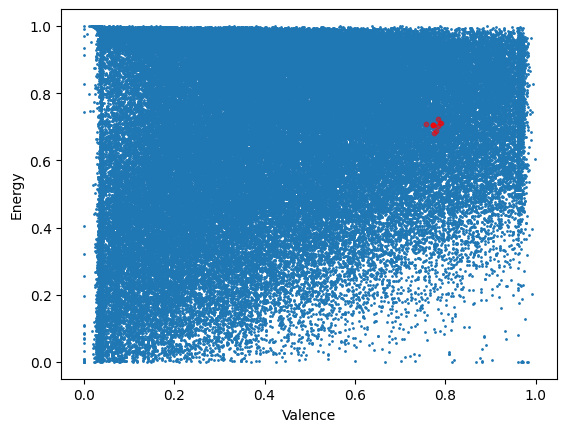

In [481]:
plot_energy_vs_valence(k_indices, metadata_df)

In [482]:
def plot_attributes(k_indices, metadata_df, features):
    # get features used by checking for non-zero weights
    features = [k for k,v in features.items() if v != 0]
    print(features)


    if (len(features) == 2):
        f1 = features[0]
        f2 = features[1]
        # plot from entire dataset
        x = metadata_df[f1].to_numpy()
        y = metadata_df[f2].to_numpy()

        # plot from recommended songs
        x_r = metadata_df.iloc[k_indices][f1].to_numpy()
        y_r = metadata_df.iloc[k_indices][f2].to_numpy()

        fig, ax = plt.subplots()
        # plot x,y for entire dataset
        ax.scatter(x, y,s=1)
        # plot x,y for recommended songs
        ax.scatter(x_r, y_r, c="Red", s=10,alpha=0.5)

        ax.set_xlabel(f"{f1}")
        ax.set_ylabel(f"{f2}")
        plt.savefig('plot_attributes.png')

        plt.show()

    elif (len(features) == 3):


        f1 = features[0]
        f2 = features[1]
        f3 = features[2]
        # plot from entire dataset
        x = metadata_df[f1].to_numpy()
        y = metadata_df[f2].to_numpy()
        z = metadata_df[f3].to_numpy()


        # plot from recommended songs


        x_r = metadata_df.iloc[k_indices][f1].to_numpy()
        y_r = metadata_df.iloc[k_indices][f2].to_numpy()
        z_r = metadata_df.iloc[k_indices][f3].to_numpy()

        fig = plt.figure()
        ax = plt.axes(projection='3d')

        # plot x,y for entire dataset
        #ax.scatter(x, y, z,s=1)
        # plot x,y for recommended songs
        ax.set_xlim(0,1)
        ax.set_ylim(0,1)
        ax.set_zlim(0,1)
        ax.scatter(x_r, y_r,z_r,c="Red", s=10,alpha=0.5)

        ax.set_xlabel(f"{f1}")
        ax.set_ylabel(f"{f2}")
        ax.set_zlabel(f"{f3}")
        fig.tight_layout()
        ax.set_box_aspect(None, zoom=0.85)
        plt.savefig('plot_attributes.png')

        plt.show()






['danceability', 'energy', 'valence']


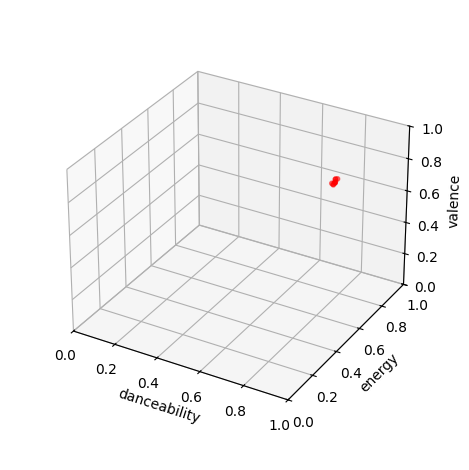

In [483]:
plot_attributes(k_indices, metadata_df, query["features"])